<a href="https://colab.research.google.com/github/Ammara-Qaisar123/Data-Science-Analytics-P2/blob/main/P_2_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Science & Analytics
Phase 2
Submitted by: Ammara Qaisar (DHC-6234)

# Task 2: Customer Segmentation Using Unsupervised Learning

## Problem Statement

Customer segmentation is one of the most important applications of unsupervised machine learning.

The objective of this project is to group customers into different segments according to their purchasing behavior.

These customer segments help businesses design personalized marketing strategies, improve customer satisfaction, and increase revenue.

K-Means Clustering is used to identify customer groups based on their annual income and spending score.

# Objective

The objectives of this project are:

- Load the Mall Customers dataset.
- Perform Exploratory Data Analysis (EDA).
- Preprocess the dataset.
- Apply K-Means Clustering.
- Determine the optimal number of clusters using the Elbow Method.
- Visualize customer segments.
- Reduce dimensions using PCA.
- Suggest marketing strategies for each customer segment.

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

# Load Dataset

The Mall Customers dataset contains demographic information and spending behavior of customers.

The dataset will be loaded using pandas.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


# Dataset Overview

Understanding the dataset is important before applying machine learning algorithms.

The following analysis includes:

- Number of rows and columns
- Data types
- Missing values
- Duplicate records
- Statistical summary

In [ ]:
print("Dataset Shape :",df.shape)

Dataset Shape : (200, 5)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.describe(include='object')

,Gender
count,200
unique,2
top,Female
freq,112


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [ ]:
df = df.drop_duplicates()

# Dataset Summary

The Mall Customers dataset contains customer demographic information and purchasing behavior.

The dataset has five attributes:

- CustomerID
- Gender
- Age
- Annual Income
- Spending Score

No missing values or duplicate records were found after preprocessing.

In [ ]:
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
82,83,Male,67,54,41
46,47,Female,50,40,55
75,76,Male,26,54,54
73,74,Female,60,50,56
189,190,Female,36,103,85
174,175,Female,52,88,13
28,29,Female,40,29,31
85,86,Male,48,54,46
124,125,Female,23,70,29
117,118,Female,49,65,59


In [ ]:
df.nunique()

,0
CustomerID,200
Gender,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


In [ ]:
df['Gender'].value_counts(normalize=True)*100

,proportion
Gender,
Female,56.0
Male,44.0


# Initial Observations

From the dataset overview, we observe that:

- The dataset contains 200 customer records.
- There are no missing values.
- The dataset includes both numerical and categorical variables.
- Gender is the only categorical feature.
- Annual Income and Spending Score are the primary variables used for customer segmentation.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the characteristics of the dataset before applying clustering algorithms.

The objectives of EDA are:

- Understand the distribution of customers.
- Analyze customer demographics.
- Explore spending behavior.
- Detect outliers.
- Discover relationships among variables.

In [ ]:
# Separate Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns")

print(numerical_columns)

print("\nCategorical Columns")

print(categorical_columns)

Numerical Columns
Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

Categorical Columns
Index(['Gender'], dtype='object')


# Customer Age Distribution

This histogram shows the age distribution of customers visiting the mall.

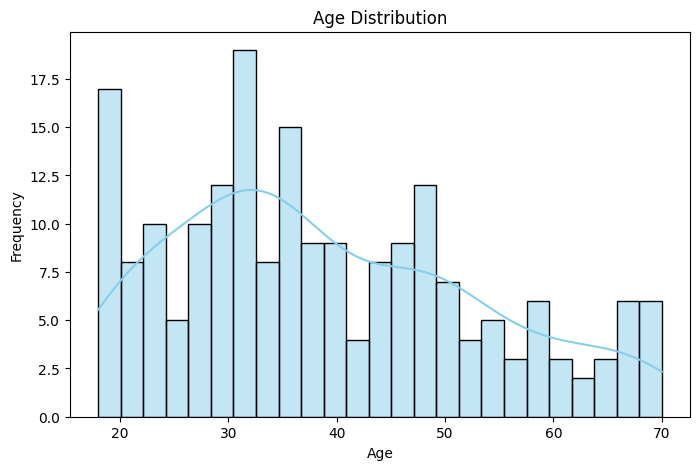

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=25, kde=True, color='skyblue')

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

# Gender Distribution

This chart illustrates the number of male and female customers.

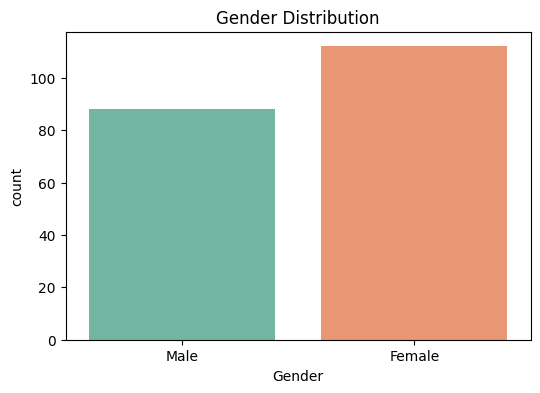

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x='Gender',palette='Set2')

plt.title("Gender Distribution")

plt.show()

# Annual Income Distribution

The histogram below represents the distribution of annual income among customers.

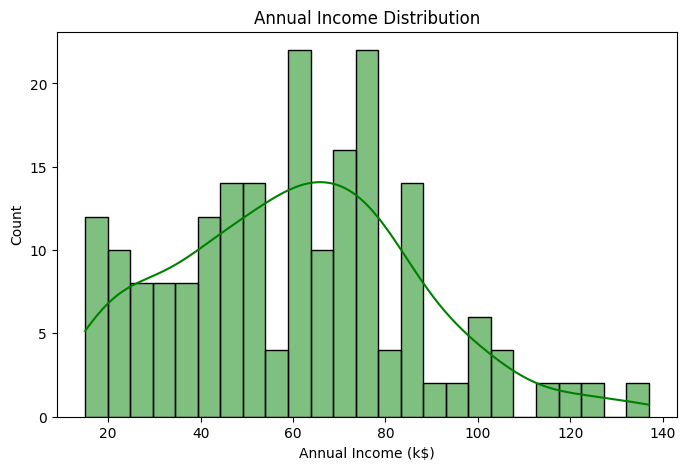

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'],bins=25,kde=True,color='green')

plt.title("Annual Income Distribution")

plt.show()

# Spending Score Distribution

The spending score reflects customer purchasing behavior.

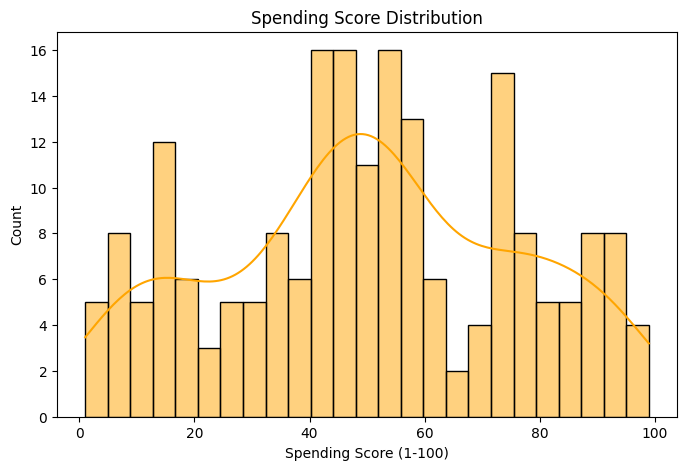

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'],bins=25,kde=True,color='orange')

plt.title("Spending Score Distribution")

plt.show()

# Boxplot of Age

Boxplots help detect outliers in numerical features.

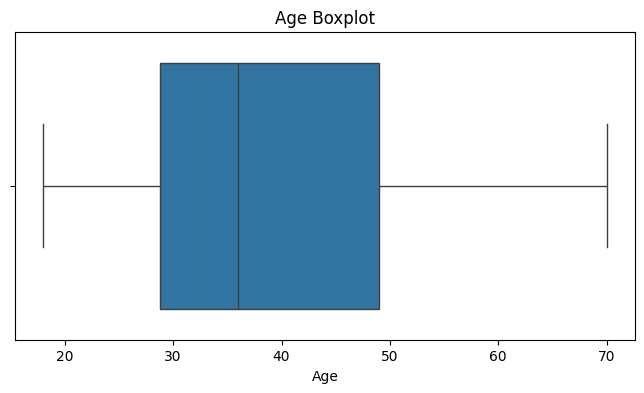

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Age'])

plt.title("Age Boxplot")

plt.show()

# Boxplot of Annual Income

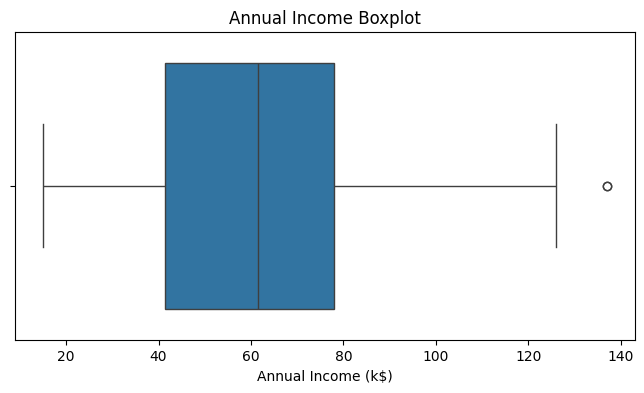

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Annual Income (k$)'])

plt.title("Annual Income Boxplot")

plt.show()

# Boxplot of Spending Score

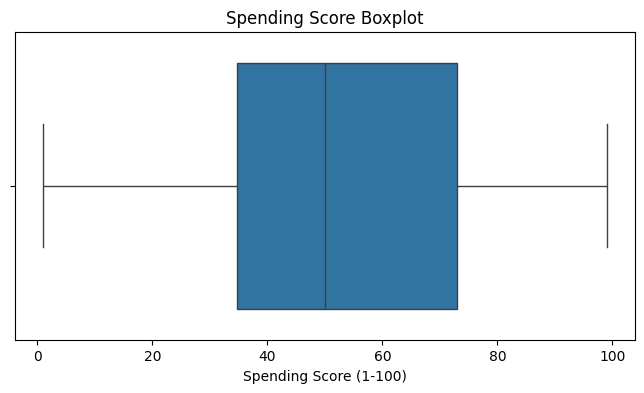

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Spending Score (1-100)'])

plt.title("Spending Score Boxplot")

plt.show()

# Annual Income by Gender

This graph compares annual income across male and female customers.

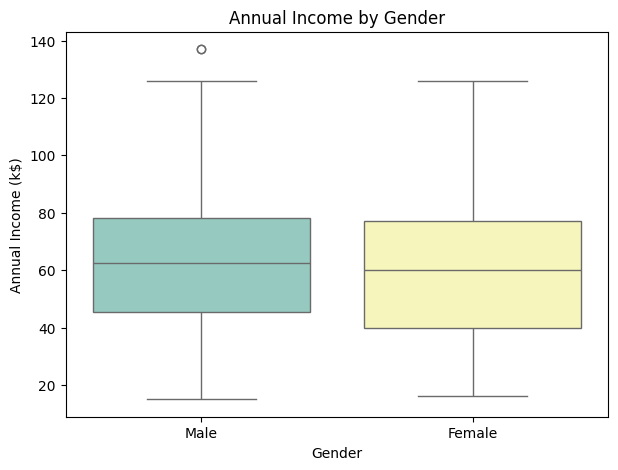

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Annual Income (k$)',
    palette='Set3'
)

plt.title("Annual Income by Gender")

plt.show()

# Spending Score by Gender

This chart compares spending behavior between male and female customers.

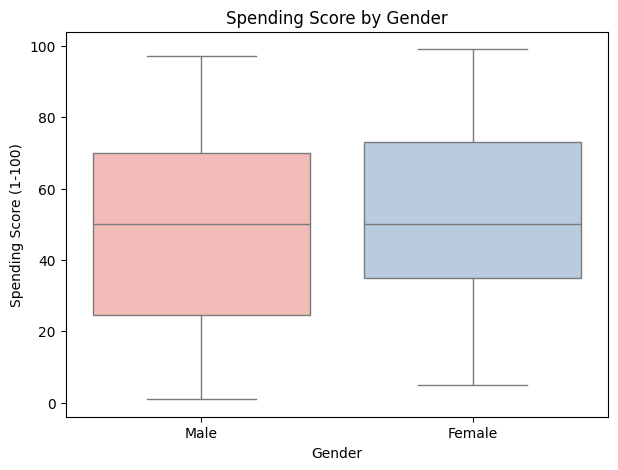

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)',
    palette='Pastel1'
)

plt.title("Spending Score by Gender")

plt.show()

# Relationship Between Annual Income and Spending Score

This scatter plot provides an initial view of potential customer groups.

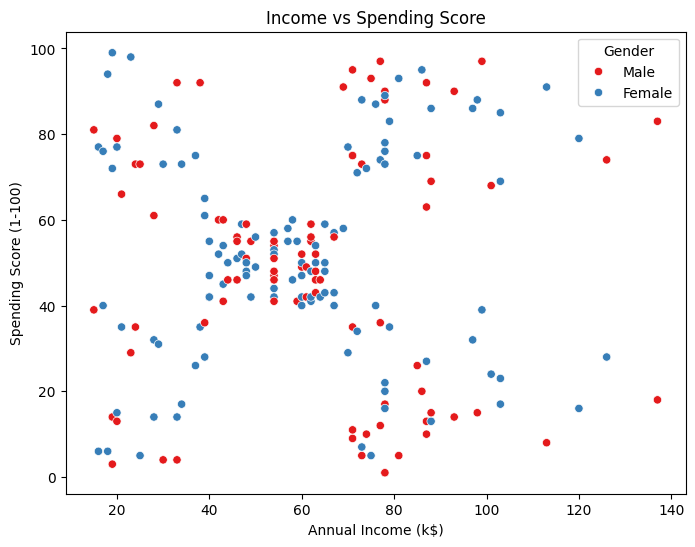

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    palette='Set1'
)

plt.title("Income vs Spending Score")

plt.show()

# Pairplot Analysis

Pairplots visualize relationships among numerical variables and can reveal natural clusters.

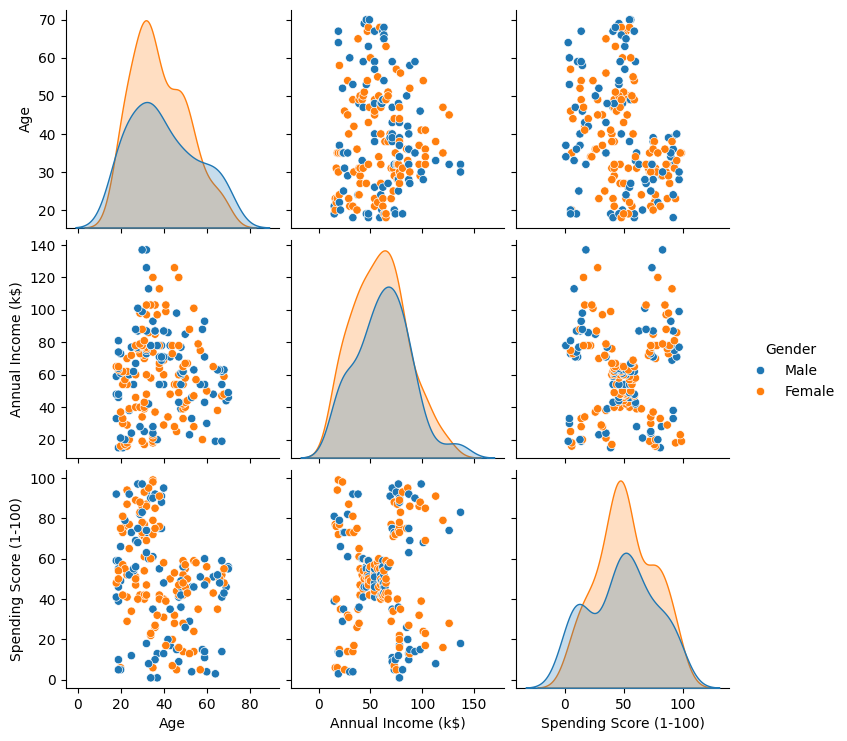

In [ ]:
sns.pairplot(
    df,
    hue='Gender',
    vars=[
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

plt.show()

# Correlation Analysis

A correlation heatmap helps identify relationships between numerical variables.

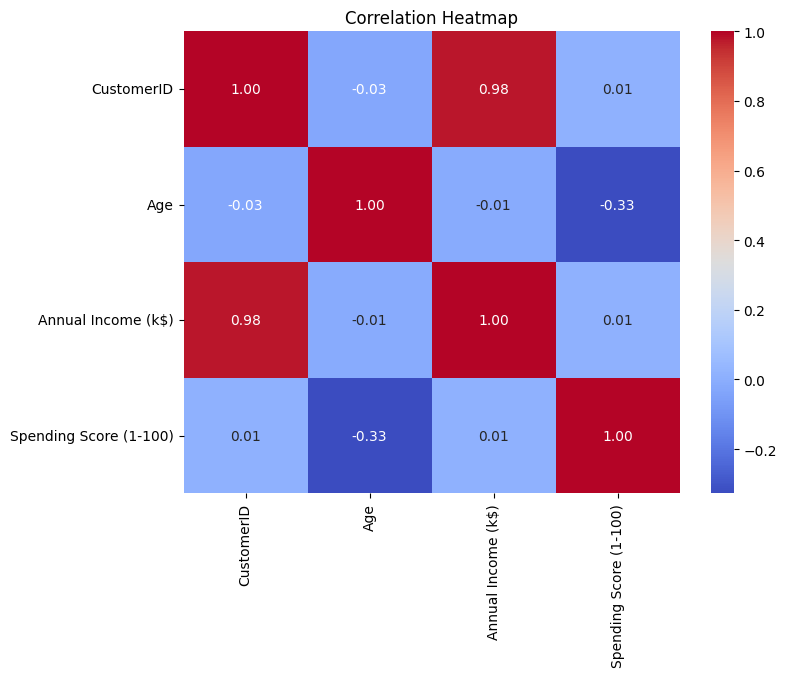

In [ ]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Insights from EDA

The exploratory analysis reveals the following:

- Customer ages are distributed across a wide range.
- Annual income and spending score show noticeable variation.
- Gender distribution is relatively balanced.
- Several distinct customer groups appear in the income versus spending score scatter plot.
- No strong linear correlation exists between all numerical variables, supporting the use of clustering techniques rather than simple linear analysis.

# Data Preprocessing

Before applying K-Means clustering, the dataset must be preprocessed.

The preprocessing steps include:

- Handling missing values
- Encoding categorical variables
- Selecting relevant features
- Scaling the data using StandardScaler

Feature scaling is essential because K-Means is a distance-based algorithm and is sensitive to differences in feature scales.

In [ ]:
# Display first five rows

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Check missing values

df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# Missing Values

The dataset is checked for missing values.

Since no missing values are present, no imputation is required.

In [ ]:
# Check data types

df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


# Encoding Gender Column

The Gender column is categorical.

It is converted into numerical values using Label Encoding so that machine learning algorithms can process it.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [ ]:
df['Gender'] = encoder.fit_transform(df['Gender'])

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


# Selecting Features for Clustering

The objective of clustering is to group customers according to their purchasing behavior.

The most informative features are:

- Annual Income (k$)
- Spending Score (1–100)

These features will be used to create customer segments.

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
print(X.shape)

(200, 2)


# Feature Scaling

The selected features have different value ranges.

StandardScaler standardizes each feature so that they have:

- Mean = 0
- Standard Deviation = 1

This prevents one feature from dominating the clustering process.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
print(X_scaled.shape)

(200, 2)


In [ ]:
type(X_scaled)

numpy.ndarray

In [ ]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


# Summary of Preprocessing

The preprocessing stage has been completed successfully.

The following tasks were performed:

- Checked for missing values.
- Encoded the Gender column.
- Selected the relevant features.
- Standardized the data using StandardScaler.

The processed dataset is now ready for K-Means clustering.

# K-Means Clustering

K-Means is an unsupervised machine learning algorithm used to group similar data points into clusters.

The algorithm works by:

- Selecting the number of clusters (K).
- Assigning each customer to the nearest cluster.
- Updating cluster centroids.
- Repeating the process until convergence.

The first step is determining the optimal number of clusters using the Elbow Method.

In [ ]:
# Import KMeans

from sklearn.cluster import KMeans

# Elbow Method

The Elbow Method helps determine the optimal number of clusters.

The Within Cluster Sum of Squares (WCSS) is calculated for different values of K.

The point where the curve bends like an elbow indicates the optimal number of clusters.

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

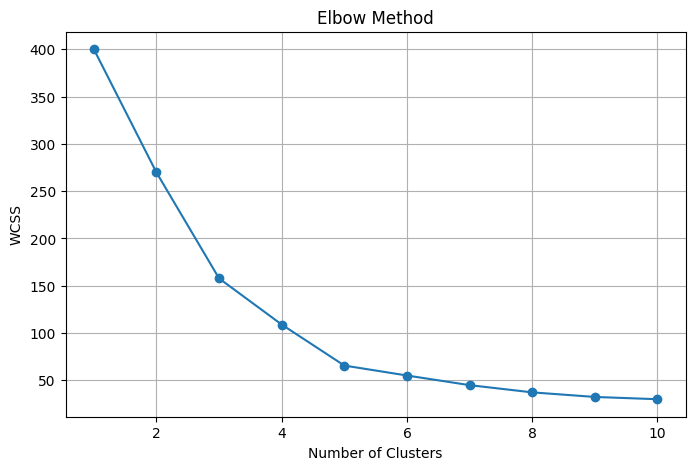

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# Selecting the Optimal Number of Clusters

From the Elbow Method, the optimal number of clusters is selected.

For the Mall Customers dataset, the elbow usually appears at **K = 5**, indicating five customer segments.

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [ ]:
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = clusters

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


# Cluster Distribution

The following table shows the number of customers assigned to each cluster.

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


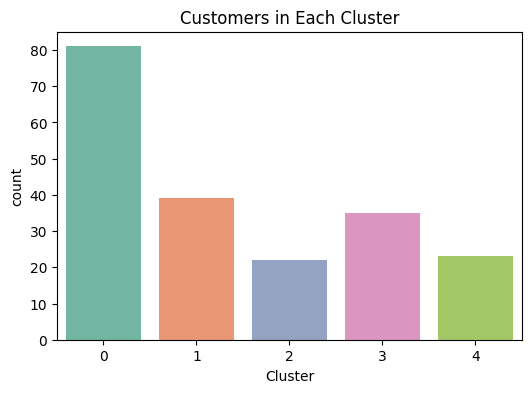

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Cluster',
    palette='Set2'
)

plt.title("Customers in Each Cluster")

plt.show()

# Customer Segmentation Visualization

Customers are visualized based on Annual Income and Spending Score.

Each color represents a different customer segment.

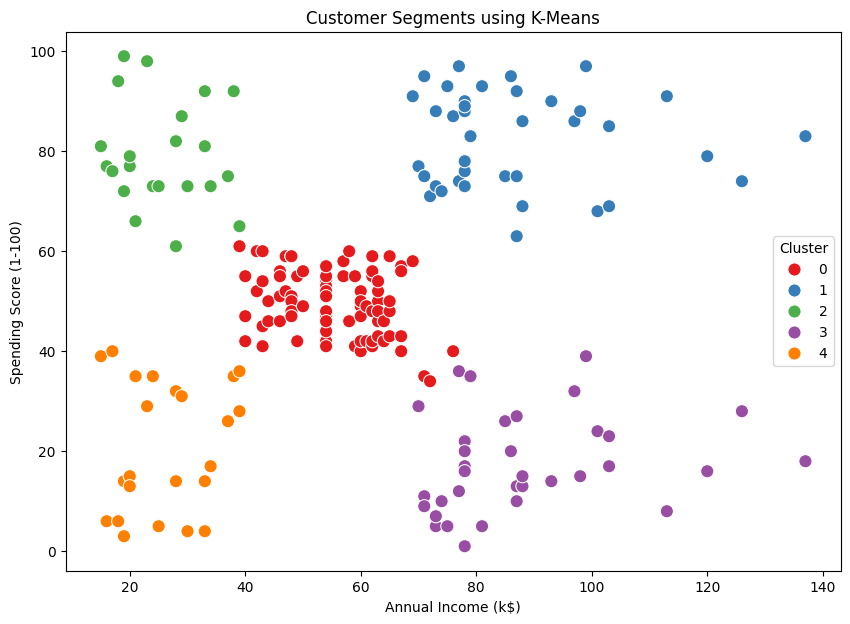

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=df,

    x='Annual Income (k$)',

    y='Spending Score (1-100)',

    hue='Cluster',

    palette='Set1',

    s=90

)

plt.title("Customer Segments using K-Means")

plt.show()

In [ ]:
centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

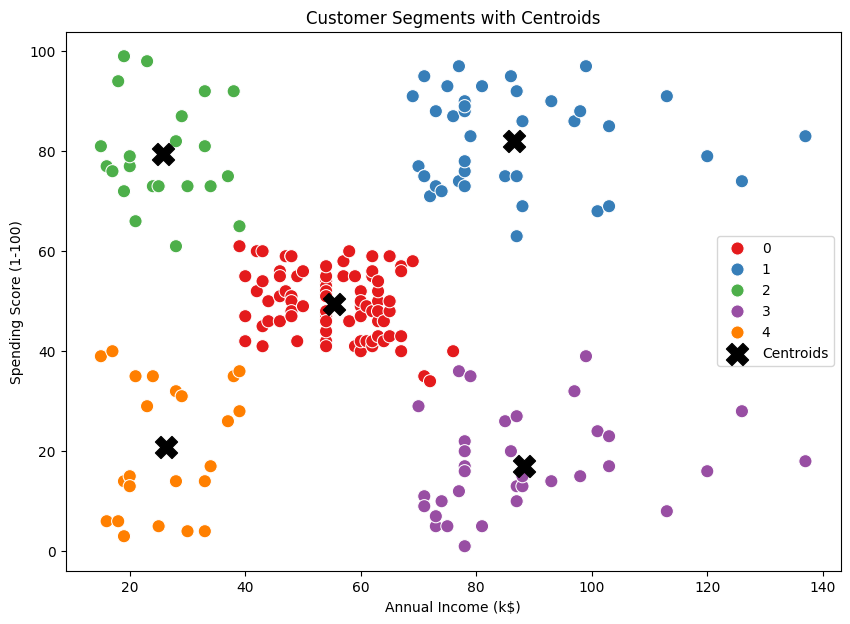

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=df,

    x='Annual Income (k$)',

    y='Spending Score (1-100)',

    hue='Cluster',

    palette='Set1',

    s=90

)

plt.scatter(

    centroids[:,0],

    centroids[:,1],

    color='black',

    marker='X',

    s=250,

    label='Centroids'

)

plt.legend()

plt.title("Customer Segments with Centroids")

plt.show()

# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

It transforms the data into two principal components while preserving most of the information.

PCA makes cluster visualization easier.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [ ]:
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-1.537109,-0.922207,4
1,-0.384168,-2.075149,2
2,-2.416002,0.010665,4
3,-0.466982,-1.938355,2
4,-1.455678,-0.895678,4


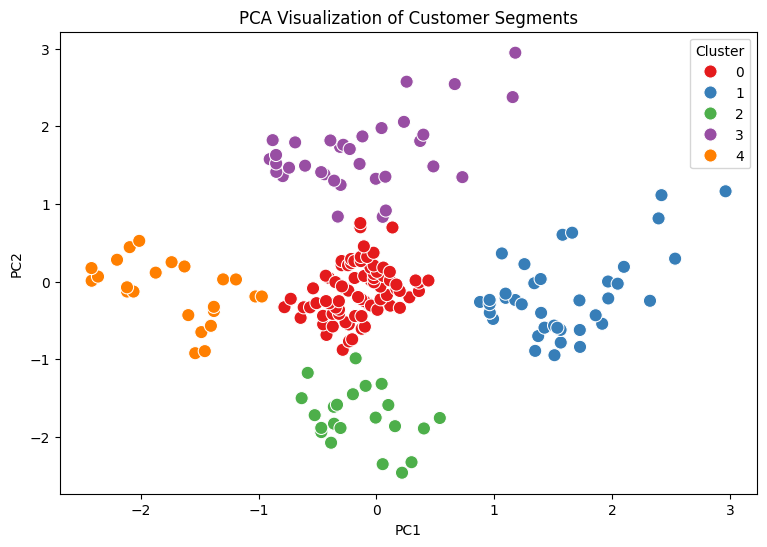

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(

    data=pca_df,

    x='PC1',

    y='PC2',

    hue='Cluster',

    palette='Set1',

    s=90

)

plt.title("PCA Visualization of Customer Segments")

plt.show()

# Silhouette Score

The Silhouette Score evaluates the quality of clustering.

A value close to **1** indicates well-separated clusters, while a value close to **0** indicates overlapping clusters.

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.555


# Cluster Summary

The average Annual Income and Spending Score for each cluster are calculated to understand customer behavior.

In [ ]:
cluster_summary = df.groupby('Cluster')[
    ['Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
cluster_summary.style.background_gradient(cmap='Blues')

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


# Customer Segment Analysis

After applying K-Means clustering, customers are grouped into different segments based on their Annual Income and Spending Score.

Each cluster represents customers with similar purchasing behavior.

Understanding these segments helps businesses design targeted marketing campaigns and improve customer satisfaction.

In [ ]:
# Display average values for each cluster

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


# Customer Segments Interpretation

The customer segments can be interpreted as follows:

### Cluster 0
- Medium Income
- Medium Spending
- Regular Customers

### Cluster 1
- High Income
- High Spending
- Premium Customers

### Cluster 2
- Low Income
- Low Spending
- Budget Customers

### Cluster 3
- High Income
- Low Spending
- Wealthy but Less Engaged Customers

### Cluster 4
- Low Income
- High Spending
- Young and Impulsive Customers

> Note: The cluster numbers (0–4) assigned by K-Means are arbitrary. Use your `cluster_summary` table to identify which numbered cluster corresponds to each customer type in your results.

# Marketing Strategies

Different customer groups require different marketing approaches.

The following strategies are recommended for each customer segment.

In [ ]:
marketing_strategy = pd.DataFrame({

'Customer Segment':[
'Premium Customers',
'Budget Customers',
'Regular Customers',
'High Income Low Spending',
'Low Income High Spending'
],

'Recommended Strategy':[

'Offer exclusive memberships, loyalty rewards, VIP discounts and premium services.',

'Provide discounts, coupons and seasonal offers to encourage purchases.',

'Maintain engagement through reward points and personalized promotions.',

'Introduce premium products, personalized recommendations and targeted advertisements.',

'Promote affordable bundles, cashback offers and limited-time promotions.'

]

})

marketing_strategy

,Customer Segment,Recommended Strategy
0,Premium Customers,"Offer exclusive memberships, loyalty rewards, ..."
1,Budget Customers,"Provide discounts, coupons and seasonal offers..."
2,Regular Customers,Maintain engagement through reward points and ...
3,High Income Low Spending,"Introduce premium products, personalized recom..."
4,Low Income High Spending,"Promote affordable bundles, cashback offers an..."


# Cluster Visualization Summary

The customer segmentation analysis identified distinct customer groups based on Annual Income and Spending Score.

The scatter plots and PCA visualization demonstrate that K-Means successfully separated customers into meaningful clusters.

These customer segments can support business decision-making and targeted marketing campaigns.

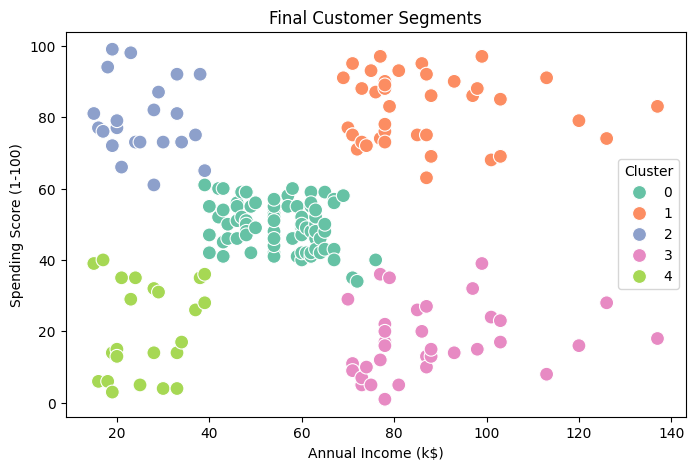

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(

data=df,

x='Annual Income (k$)',

y='Spending Score (1-100)',

hue='Cluster',

palette='Set2',

s=100

)

plt.title("Final Customer Segments")

plt.show()

# Business Insights

The clustering analysis provides several useful business insights:

- Premium customers should receive loyalty rewards and exclusive services.
- Budget customers are more responsive to discounts and promotional offers.
- Regular customers should be encouraged to increase purchase frequency.
- High-income customers with low spending represent an opportunity for targeted marketing.
- High-spending customers with lower income may respond well to installment plans, cashback offers, and personalized promotions.

# Conclusion

This project successfully applied K-Means Clustering to segment mall customers based on Annual Income and Spending Score.

The Elbow Method was used to determine the optimal number of clusters, and Principal Component Analysis (PCA) was used to visualize customer segments.

The clustering results identified distinct customer groups with different purchasing behaviors.

These insights can help businesses develop personalized marketing strategies, improve customer satisfaction, and increase overall sales.

Overall, this project demonstrates how unsupervised machine learning techniques can transform raw customer data into actionable business insights.

# Future Work

Future improvements to this project may include:

- Applying other clustering algorithms such as DBSCAN or Hierarchical Clustering.
- Using additional customer attributes such as purchase history and product preferences.
- Comparing PCA with t-SNE for visualization.
- Building an interactive customer segmentation dashboard using Streamlit.
- Integrating real-time customer data for dynamic segmentation.

In [ ]:
print("="*60)
print("Task 2 Completed Successfully")
print("="*60)

print("\nProject Summary")

print("- Dataset Loaded Successfully")
print("- Exploratory Data Analysis Completed")
print("- Data Preprocessing Completed")
print("- Feature Scaling Completed")
print("- K-Means Clustering Applied")
print("- PCA Visualization Completed")
print("- Marketing Strategies Proposed")
print("- Business Insights Generated")
print("- Final Conclusion Written")

print("\nCustomer Segmentation Project Completed.")

Task 2 Completed Successfully

Project Summary
- Dataset Loaded Successfully
- Exploratory Data Analysis Completed
- Data Preprocessing Completed
- Feature Scaling Completed
- K-Means Clustering Applied
- PCA Visualization Completed
- Marketing Strategies Proposed
- Business Insights Generated
- Final Conclusion Written

Customer Segmentation Project Completed.
